In [1]:
import sys
print(sys.executable)


d:\Final Year Project\ImageProcessing\.venv\Scripts\python.exe


In [4]:
import importlib

modules = ["tensorflow", "numpy", "matplotlib", "sklearn"]

for m in modules:
    try:
        importlib.import_module(m)
        print(f"{m}: INSTALLED")
    except ImportError:
        print(f"{m}: NOT INSTALLED")


tensorflow: INSTALLED
numpy: INSTALLED
matplotlib: INSTALLED
sklearn: INSTALLED


In [2]:
!pip install scikit-learn --quiet


NameError: name 'check_lib' is not defined

In [2]:
# Cell 1: Import required libraries
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Model
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.optimizers import Adam
import matplotlib.pyplot as plt
import numpy as np
import os

# Verify TensorFlow version
print("TensorFlow version:", tf.__version__)


TensorFlow version: 2.17.1


In [4]:
# Cell 2: Load dataset (preprocessed lesion images)

train_dir = r"D:\Final Year Project\ImageProcessing\Dataset"
val_dir = r"D:\Final Year Project\ImageProcessing\Dataset"

IMG_SIZE = (224, 224)
BATCH_SIZE = 32

train_datagen = ImageDataGenerator(rescale=1./255, rotation_range=15, horizontal_flip=True)
val_datagen = ImageDataGenerator(rescale=1./255)

train_data = train_datagen.flow_from_directory(
    train_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

val_data = val_datagen.flow_from_directory(
    val_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)


FileNotFoundError: [WinError 3] The system cannot find the path specified: 'D:\\Final Year Project\\ImageProcessing\\Dataset'

In [5]:
# Cell 3: Build the model using MobileNetV2 as feature extractor
base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dropout(0.3)(x)
predictions = Dense(train_data.num_classes, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=predictions)

# Freeze pretrained layers for feature extraction
for layer in base_model.layers:
    layer.trainable = False

# Compile model
model.compile(optimizer=Adam(learning_rate=1e-4),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

model.summary()


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


NameError: name 'train_data' is not defined

In [6]:
# Cell 4: Train the model
EPOCHS = 10

history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=EPOCHS
)


NameError: name 'model' is not defined

NameError: name 'history' is not defined

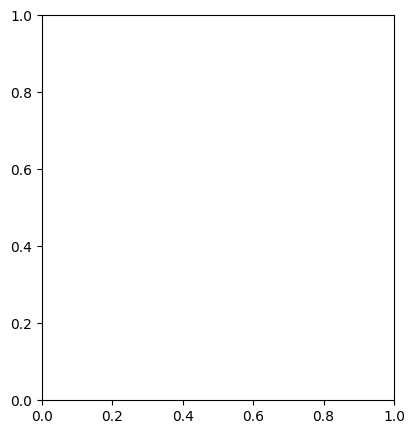

In [7]:
# Cell 5: Plot accuracy and loss
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.legend()
plt.title("Accuracy")

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.legend()
plt.title("Loss")

plt.show()


In [8]:
# Cell 6: Evaluate and save the trained model
loss, acc = model.evaluate(val_data)
print(f"Validation Accuracy: {acc*100:.2f}%")

# Save Keras model (optional)
model.save("skin_disease_model.h5")
print("Keras model saved successfully.")


NameError: name 'model' is not defined

In [9]:
# Cell 7: Convert to TensorFlow Lite format for Android
converter = tf.lite.TFLiteConverter.from_keras_model(model)
tflite_model = converter.convert()

# Save the TFLite model
tflite_path = "skin_disease_model.tflite"
with open(tflite_path, "wb") as f:
    f.write(tflite_model)

print("TFLite model exported successfully:", tflite_path)


NameError: name 'model' is not defined

In [10]:
# Cell 8: Save class labels (for Android app)
labels = list(train_data.class_indices.keys())
print("Detected classes:", labels)

with open("labels.txt", "w") as f:
    for label in labels:
        f.write(f"{label}\n")

print("Labels file saved successfully.")


NameError: name 'train_data' is not defined

In [11]:
# Cell 9: Test model on one image (for verification)
from tensorflow.keras.preprocessing import image
import numpy as np

sample_path = r"D:\Final Year Project\ImageProcessing\Images\Melanoma_1.jpg"
img = image.load_img(sample_path, target_size=IMG_SIZE)
img_array = image.img_to_array(img) / 255.0
img_array = np.expand_dims(img_array, axis=0)

pred = model.predict(img_array)
predicted_class = labels[np.argmax(pred)]
confidence = np.max(pred) * 100

print(f"Prediction: {predicted_class} ({confidence:.2f}%)")


NameError: name 'model' is not defined